<a href="https://colab.research.google.com/github/rohan604037/HPC_Orange/blob/main/gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from numba import cuda
import math
import time

In [2]:
SOBEL_X = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]], dtype=np.float32)
SOBEL_Y = np.array([[-1,-2,-1],
                    [0,0,0],
                    [1,2,1]], dtype=np.float32)

In [3]:
@cuda.jit
def sobel_cuda(img, output):
    x, y = cuda.grid(2)
    if x >= 1 and y >= 1 and x < img.shape[0]-1 and y < img.shape[1]-1:
        gx = 0.0
        gy = 0.0
        for i in range(-1,2):
            for j in range(-1,2):
                pixel = img[x+i, y+j]
                gx += pixel * SOBEL_X[i+1,j+1]
                gy += pixel * SOBEL_Y[i+1,j+1]
        output[x,y] = math.sqrt(gx*gx + gy*gy)

In [4]:
img = cv2.imread('/content/test.png', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (1024,1024))
img = img.astype(np.float32)

In [5]:
def sobel_cpu(img):
    h, w = img.shape
    output = np.zeros_like(img)
    for x in range(1,h-1):
        for y in range(1,w-1):
            gx = 0
            gy = 0
            for i in range(-1,2):
                for j in range(-1,2):
                    pixel = img[x+i,y+j]
                    gx += pixel * SOBEL_X[i+1,j+1]
                    gy += pixel * SOBEL_Y[i+1,j+1]
            output[x,y] = math.sqrt(gx*gx + gy*gy)
    return output

In [6]:
start = time.time()
cpu_output = sobel_cpu(img)
cpu_time = time.time() - start
print("CPU time:", cpu_time)

CPU time: 8.709733486175537


In [8]:
d_img = cuda.to_device(img)
d_output = cuda.device_array_like(img)
threads_per_block = (16, 16)
blocks_per_grid_x = (img.shape[0] + threads_per_block[0] - 1) // threads_per_block[0]
blocks_per_grid_y = (img.shape[1] + threads_per_block[1] - 1) // threads_per_block[1]
blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)
# PRINT INFORMATION
print("Image size:", img.shape)
print("Threads per block:", threads_per_block)
print("Threads per block (total):", threads_per_block[0]*threads_per_block[1])
print("Blocks per grid:", blocks_per_grid)
print("Total blocks:", blocks_per_grid[0]*blocks_per_grid[1])
total_threads = (threads_per_block[0] * threads_per_block[1] *
blocks_per_grid[0] * blocks_per_grid[1])
print("Total threads launched:", total_threads)

Image size: (1024, 1024)
Threads per block: (16, 16)
Threads per block (total): 256
Blocks per grid: (64, 64)
Total blocks: 4096
Total threads launched: 1048576


In [9]:
start = time.time()
sobel_cuda[blocks_per_grid, threads_per_block](d_img, d_output)
cuda.synchronize()
gpu_time = time.time() - start
gpu_output = d_output.copy_to_host()
print("GPU time:", gpu_time)
print("Speedup:", cpu_time/gpu_time)

GPU time: 1.9439663887023926
Speedup: 4.480393044238449


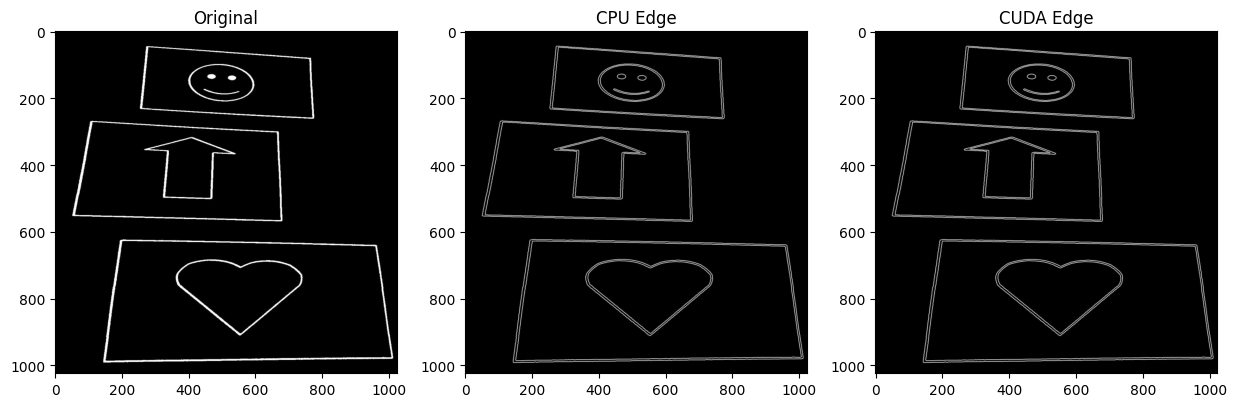

In [10]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.subplot(1,3,2)
plt.title("CPU Edge")
plt.imshow(cpu_output, cmap='gray')
plt.subplot(1,3,3)
plt.title("CUDA Edge")
plt.imshow(gpu_output, cmap='gray')
plt.show()